In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sms
from datetime import datetime
plt.style.use('dark_background')

In [3]:
df = pd.read_csv(r"./traffic_dataset_with_trend.csv")
df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='%Y-%m-%d %H:%M:%S')
df.set_index('Timestamp',inplace=True)
df.sort_index()
df.head(2)

,Weather,Events,Traffic Volume
Timestamp,,,
2023-01-01 00:00:00,Cloudy,False,803.0
2023-01-01 01:00:00,Clear,False,861.0


In [4]:
sun_n_df = df[(df['Events']==False) & (df['Weather']=='Clear') & (df['Traffic Volume']<600)].copy()
sun_n_df['Hour'] = sun_n_df.index.hour
sun_n_df['Hour'].value_counts().head(5)

Hour
6     21
2     17
1     16
0     15
23    15
Name: count, dtype: int64

In [5]:
sun_n_df.columns

Index(['Weather', 'Events', 'Traffic Volume', 'Hour'], dtype='object')

In [6]:
sun_df = df[df['Weather']=='Clear']
pd.pivot_table(index=sun_df.index.hour,values=['Traffic Volume'],aggfunc='mean',columns=['Events'],data=sun_df).sort_values(by=[('Traffic Volume', False), ('Traffic Volume', True)])

Traffic Volume             
Events             False        True 
Timestamp                            
23            911.173469  2423.000000
1             912.374359  2289.739130
3             931.934426  2707.391304
6             933.765957  3204.666667
2             939.838095  2207.800000
0             943.099502  2930.275862
4             943.790323  2842.000000
22            952.543590  2668.238095
5             962.020942  2478.562500
21            964.803109  2807.518519
17            994.470270  2889.862069
19            996.353846  2464.318182
20            999.403141  2905.423077
18           1010.700441  2645.769231
10           1271.905941  3638.058824
15           1272.203209  3166.111111
8            1280.927374  3210.055556
13           1287.879781  3032.129032
11           1295.804124  3121.000000
9            1299.473118  3179.090909
14           1299.550000  3123.538462
7            1302.939086  2804.666667
12           1309.092391  3577.785714
16           1334.597015  2927.625000

on clear days, 1 am to 2 am traffic is less whether there is event or not</br>
and normal days that is clear day and no event, traffic is usually less from 11pm to 6 am

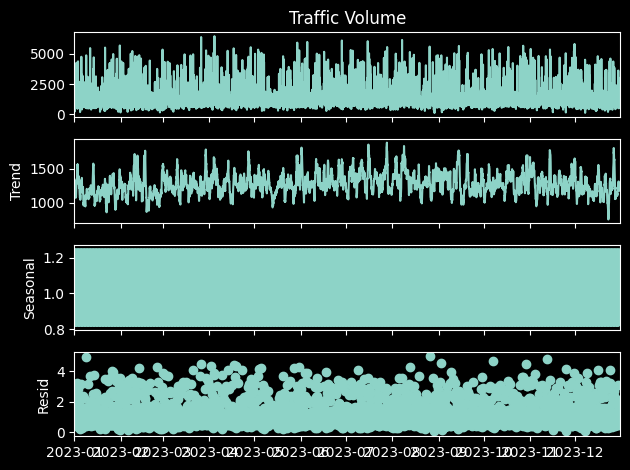

In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose, STL
res = seasonal_decompose(df['Traffic Volume'],model='multiplicative',period=24)
res.plot()
plt.show()

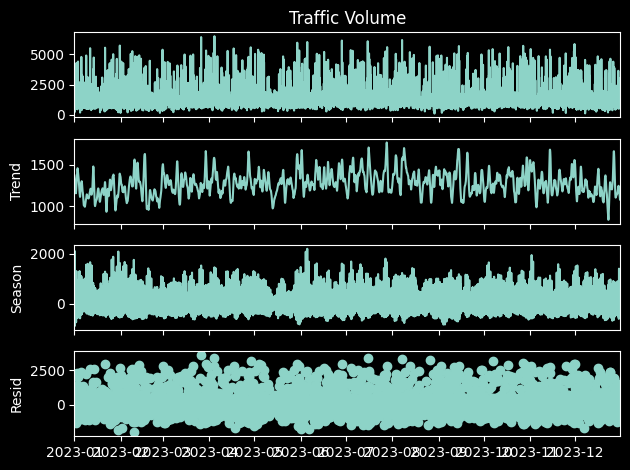

In [8]:
stl = STL(df['Traffic Volume'], period=24)
res = stl.fit()
res.plot()
plt.show()

In [9]:
from statsmodels.tsa.stattools import adfuller
r = adfuller(df['Traffic Volume'])
r[1]<0.05

True

In [10]:
df['Traffic Volume_S'] = df['Traffic Volume'].diff(24)

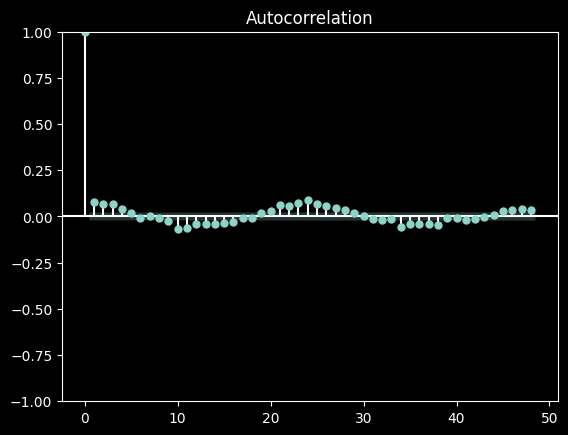

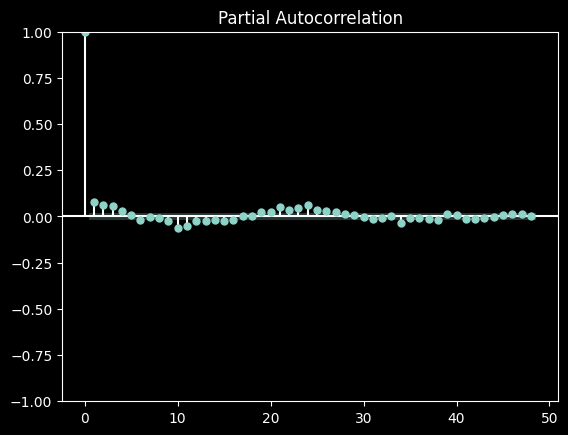

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
acf_plot = plot_acf(df['Traffic Volume_S'].dropna(),lags=48)
pacf_plot = plot_pacf(df['Traffic Volume_S'].dropna(),lags=48)

In [12]:
exog = pd.get_dummies(df[['Events','Weather']],drop_first=True)

In [13]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
y = df['Traffic Volume']
train_ex = exog.iloc[0:8000]
test_ex = exog.iloc[8000:]
y_train = y.iloc[0:8000]
y_test = y.iloc[8000:]
train_ex = train_ex.astype(int)
test_ex = test_ex.astype(int)
model = SARIMAX(y_train, 
                exog=train_ex, 
                order=(0, 0, 0),      
                seasonal_order=(2, 1, 1, 24)) 
results = model.fit()

# Print summary
print(results.summary())

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


                                 SARIMAX Results                                  
Dep. Variable:             Traffic Volume   No. Observations:                 8000
Model:             SARIMAX(2, 1, [1], 24)   Log Likelihood              -60249.933
Date:                    Tue, 18 Feb 2025   AIC                         120515.866
Time:                            19:17:11   BIC                         120571.740
Sample:                        01-01-2023   HQIC                        120534.994
                             - 11-30-2023                                         
Covariance Type:                      opg                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Events          1778.4100      8.600    206.790      0.000    1761.554    1795.266
Weather_Cloudy     0.6722     11.394      0.059      0.953     -21.659      23.003
Weat

In [14]:
forecast = results.get_forecast(steps=len(test_ex), exog=test_ex)
forecast_values = forecast.predicted_mean
forecast_conf_int = forecast.conf_int()
from sklearn.metrics import root_mean_squared_error as rmse, mean_absolute_percentage_error as mape,r2_score
print("rmse: ",rmse(forecast_values,y_test))
print("r2: ",r2_score(y_pred=forecast_values,y_true=y_test))

rmse:  457.27587143744915
r2:  0.6035643249277329


In [15]:
test_df = pd.DataFrame({'Traffic':y_test,'Traffic forecast':forecast_values})

<Axes: >

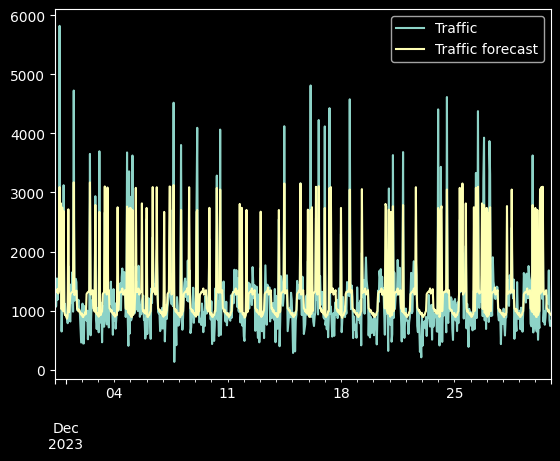

In [16]:
test_df[['Traffic','Traffic forecast']].plot()

Forecasted Values: 200
mape: 0.2666907382375949
rmse-  538.0333096296059
r2_score-  0.28705567872909843


<Axes: xlabel='Timestamp'>

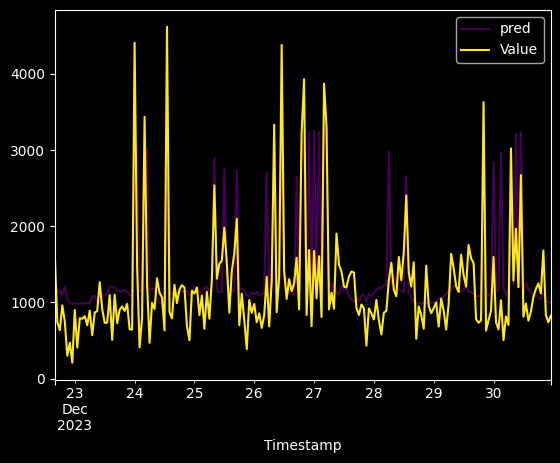

In [17]:
from sklearn.base import BaseEstimator, TransformerMixin, RegressorMixin
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import Normalizer
from feature_engine.timeseries.forecasting import ExpandingWindowFeatures, LagFeatures, WindowFeatures
class LaggedFeatures(BaseEstimator,TransformerMixin):
    def __init__(self,var='Value',p=[1,7,30,12]):
        self.var = var
        self.p = p
    def fit(self,X,y=None):
        return self
    def transform(self, X):
        lag_trans = LagFeatures(variables=[self.var],periods=self.p)
        df_lagged = lag_trans.fit_transform(X[[self.var]])
        df_lagged.drop(columns=[self.var],inplace=True)
        return df_lagged
    
class RolledFeatures(BaseEstimator,TransformerMixin):
    def __init__(self,var='Value',w=3):
        self.var = var
        self.w = w
    def fit(self,X,y=None):
        return self
    def transform(self, X):
        roll_trans = WindowFeatures(variables=[self.var],window=self.w,functions=['mean', 'std', 'max','min'])
        df_roll = roll_trans.fit_transform(X[[self.var]])
        df_roll.drop(columns=[self.var],inplace=True)
        return df_roll
    
class ExpandFeatures(BaseEstimator,TransformerMixin):
    def __init__(self,var='Value'):
        self.var = var
    def fit(self,X,y=None):
        return self
    def transform(self, X):
        expan_trans = ExpandingWindowFeatures(variables=[self.var],functions=['mean', 'std'])
        df_expand = expan_trans.fit_transform(X[[self.var]])
        df_expand.drop(columns=[self.var],inplace=True)
        return df_expand
class ExogFeatures(BaseEstimator,TransformerMixin):
    def __init__(self,var='Events',weather='Weather'):
        self.weather = weather
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        df_exog = pd.get_dummies(X[[self.weather]],drop_first=True)
        df_exog['Events']=X['Events']
        return df_exog   
features = FeatureUnion([
        ('lag',LaggedFeatures(p=[1,2,6,9,12,24])),
        ('roll',RolledFeatures(w=[3,6,12,24])),
        ('exp',ExpandFeatures()),
        ('exog',ExogFeatures(var='Events',weather='Weather'))
    ])

class Forcaster(BaseEstimator,RegressorMixin):
    def __init__(self,model,lag=13): 
        self.model = model
        self.lag = lag
    def fit(self,X,y):
        self.model.fit(X,y)
        self.last = y[-self.lag:]
        return self
    def predict(self, X):
        return self.model.predict(X)
    def forecast(self,pipeline,y,steps,exog):
        forecasts = []
        freq = pd.infer_freq(y.index) or y.index.freqstr
        future_indices = pd.date_range(start=y.index[-1], periods=steps + 2, freq=freq)[1:]
        dummy =0
        prev = future_indices[0]
        new_entry = pd.Series(dummy, index=[future_indices[0]],name='Value')
        y = pd.concat([y, new_entry])
        for next_timestamp in future_indices[1:]:
            y['Events']=df.loc[:next_timestamp]['Events']
            y['Weather']=df.loc[:next_timestamp]['Weather']
            last_features = pipeline.named_steps['features'].transform(y)
            next_value = pipeline.named_steps['model'].predict(last_features[-1].reshape(1,-1))
            forecasts.append(next_value[0])
            y.loc[prev, "Value"]= next_value
            new_entry = pd.Series(dummy, index=[next_timestamp],name='Value')
            y = pd.concat([y, new_entry])
            prev= next_timestamp
        return forecasts
pipeline = Pipeline([
    ('features', features),
    ('model', Forcaster(model=RandomForestRegressor(random_state=42,criterion='squared_error',max_depth=5,n_estimators= 50,n_jobs=-1,oob_score=True),lag=13))
])
step=200
tdf = df.iloc[:-step].copy()
testdf = df.iloc[-step:]
tdf = tdf.rename(columns={'Traffic Volume':'Value'})
df = df.rename(columns={'Traffic Volume':'Value'})
pipeline.fit(tdf.drop(columns=['Traffic Volume_S']),tdf['Value'])
forecasted_values = pipeline.named_steps['model'].forecast(pipeline=pipeline,steps=step,y=tdf[['Value']],exog=df[['Events','Weather']])
print("Forecasted Values:", len(forecasted_values))
print("mape:", mape(forecasted_values,df['Value'].iloc[-step:]))
print("rmse- ",rmse(forecasted_values,df['Value'].iloc[-step:]))
print("r2_score- ",r2_score(forecasted_values,df['Value'].iloc[-step:]))
tedf= df.iloc[-step:].copy()
tedf['pred'] = forecasted_values
tedf[['pred','Value']].plot(colormap='viridis')

using both models, we tried to predict daily traffic rate but there are lot of fluctuations, so we will predict daily traffic

<Axes: xlabel='Timestamp'>

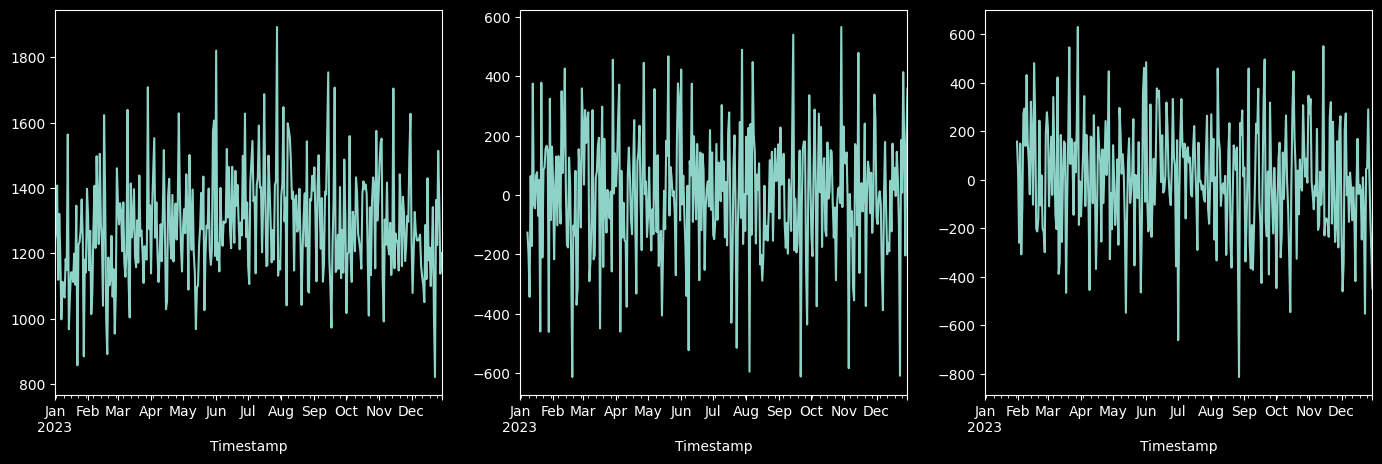

In [32]:
day_df = df['Value'].resample('D').mean().to_frame(name='Value')
day_df['Week_Val'] = day_df['Value'].diff(7)
day_df['Mon_Val'] = day_df['Value'].diff(30)
fig,ax = plt.subplots(ncols=3,nrows=1,figsize=(17,5))
day_df['Value'].plot(ax=ax[0])
day_df['Week_Val'].plot(ax=ax[1])
day_df['Mon_Val'].plot(ax=ax[2])

In [28]:
r = adfuller(day_df['Value'])
r[1]<0.05

True

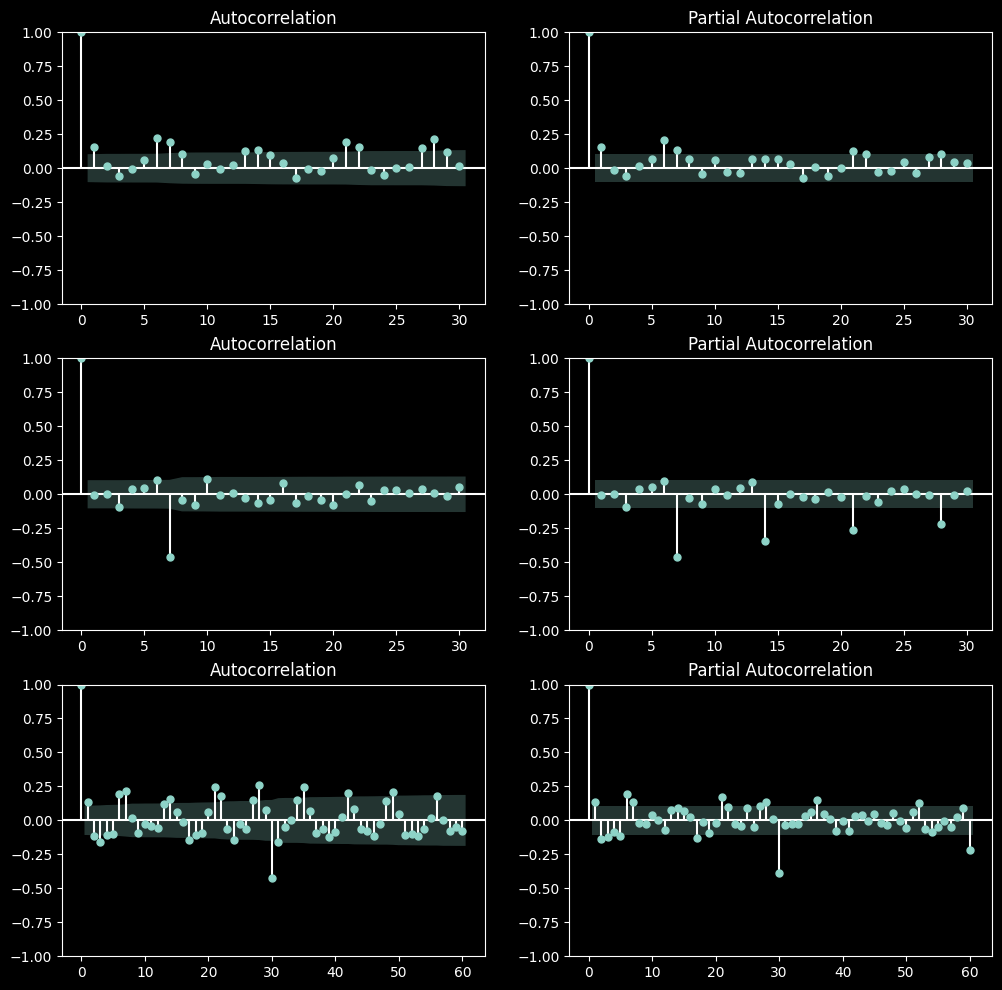

In [37]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
fig,ax = plt.subplots(ncols=2,nrows=3,figsize=(12,12))
acf_plot = plot_acf(day_df['Value'].dropna(),lags=30,ax=ax[0,0])
pacf_plot = plot_pacf(day_df['Value'].dropna(),lags=30,ax=ax[0,1])
acf_plot = plot_acf(day_df['Week_Val'].dropna(),lags=30,ax=ax[1,0])
pacf_plot = plot_pacf(day_df['Week_Val'].dropna(),lags=30,ax=ax[1,1])
acf_plot = plot_acf(day_df['Mon_Val'].dropna(),lags=60,ax=ax[2,0])
pacf_plot = plot_pacf(day_df['Mon_Val'].dropna(),lags=60,ax=ax[2,1])

In [54]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
y = day_df['Value']
y_train = y.iloc[0:260]
y_test = y.iloc[260:]
model = SARIMAX(y_train,  
                order=(3, 0, 3),      
                seasonal_order=(3, 0, 1, 7)) 
results = model.fit()

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  w

rmse:  170.1769159110184
r2:  -0.25437062153465084


<Axes: >

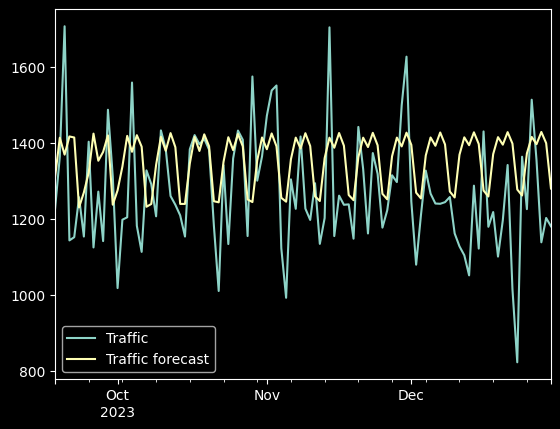

In [55]:
forecast = results.forecast(steps=len(y_test))
from sklearn.metrics import root_mean_squared_error as rmse, mean_absolute_percentage_error as mape,r2_score
print("rmse: ",rmse(forecast,y_test))
print("r2: ",r2_score(y_pred=forecast,y_true=y_test))
test_df = pd.DataFrame({'Traffic':y_test,'Traffic forecast':forecast})
test_df[['Traffic','Traffic forecast']].plot()

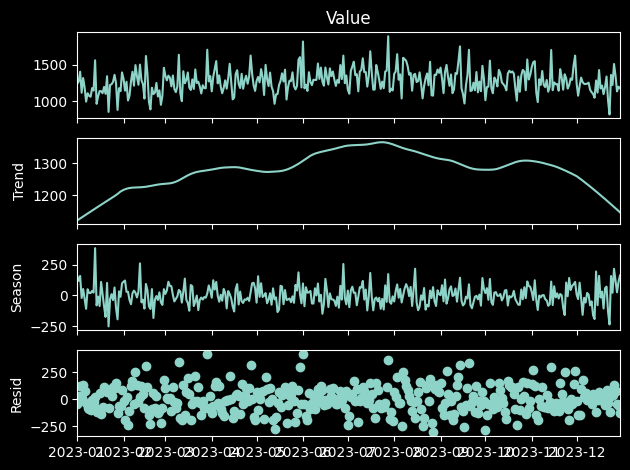

In [112]:
stl = STL(day_df['Value'], period=30)
res = stl.fit()
res.plot()
plt.show()

<Axes: xlabel='Timestamp'>

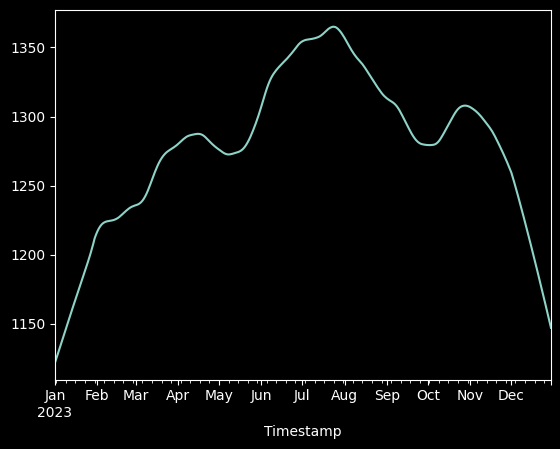

In [127]:
day_df['Trend'] = res.trend
day_df['Seas'] = res.seasonal
day_df['Res'] = res.resid
day_df['Trend'].plot()

39.78419960605889

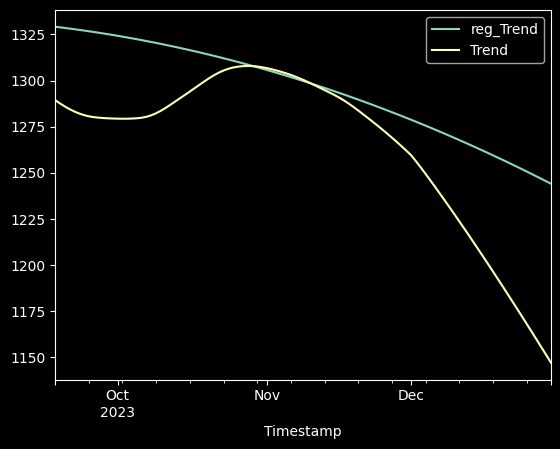

In [128]:
from numpy.polynomial.polynomial import Polynomial
train = day_df.iloc[:260].copy()
test = day_df.iloc[260:].copy()
x= np.arange(len(day_df['Trend'].dropna()))
p=Polynomial.fit(x,day_df['Trend'].dropna(),deg=2)
pred = p(np.arange(len(train.dropna()['Trend']), len(day_df.dropna()['Trend'])))
test['reg_Trend']=pred
test[['reg_Trend','Trend']].plot()
rmse(test['reg_Trend'],test['Trend'])

In [118]:
test.shape

(104, 9)

In [172]:
pred_seas = train['Seas'].groupby(train.index.day).mean()
pred_seas = np.tile(pred_seas,4)[:len(test)]
test['Pred_Seas'] = pred_seas

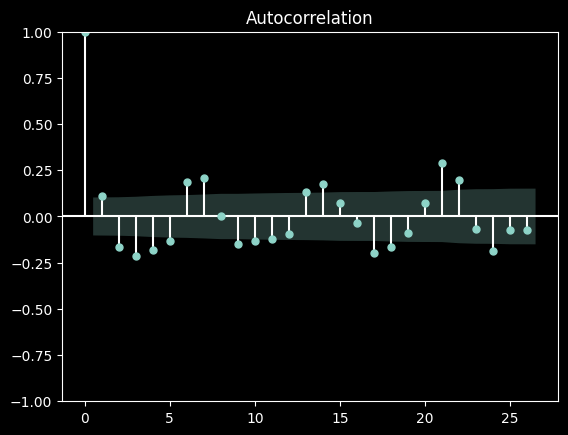

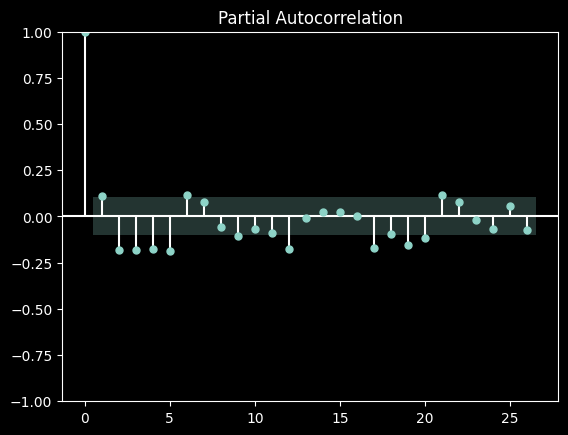

In [131]:
acf = plot_acf(day_df['Res'].dropna())
pacf = plot_pacf(day_df['Res'].dropna())

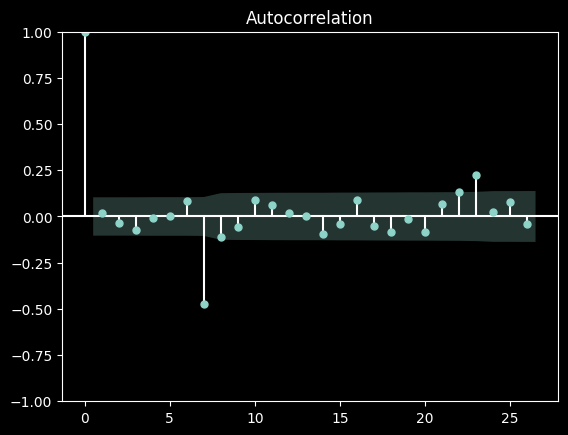

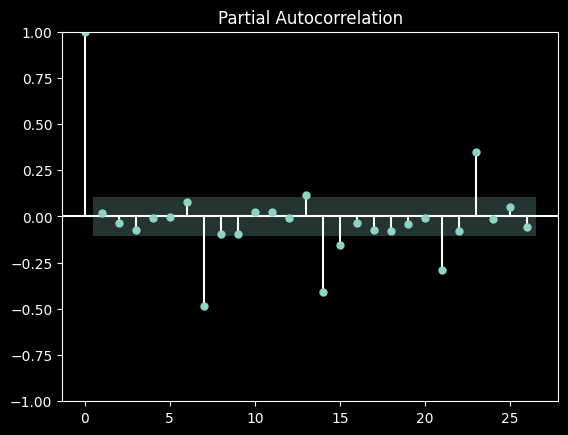

In [133]:
acf = plot_acf(day_df['Res'].diff(7).dropna())
pacf = plot_pacf(day_df['Res'].diff(7).dropna())

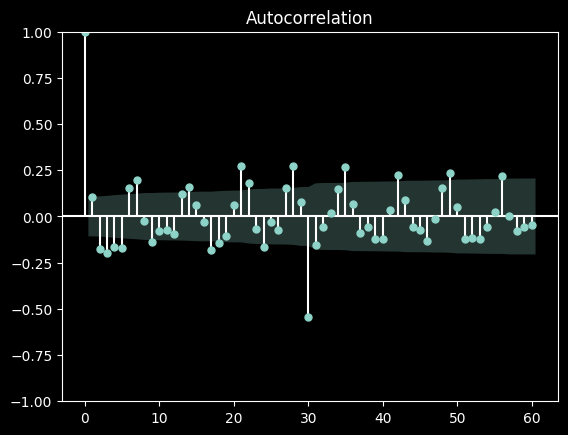

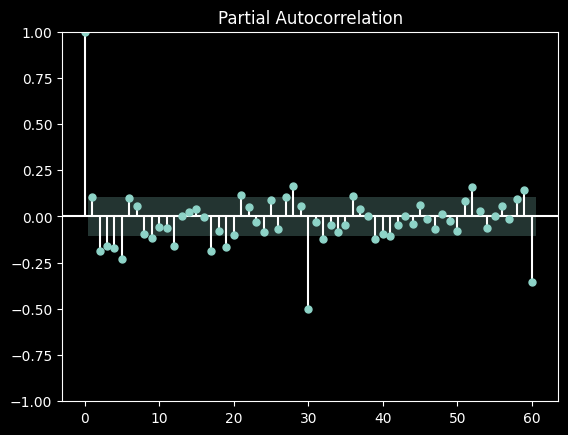

In [169]:
acf = plot_acf(day_df['Res'].diff(30).dropna(),lags=60)
pacf = plot_pacf(day_df['Res'].diff(30).dropna(),lags=60)

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


91.4978459201025

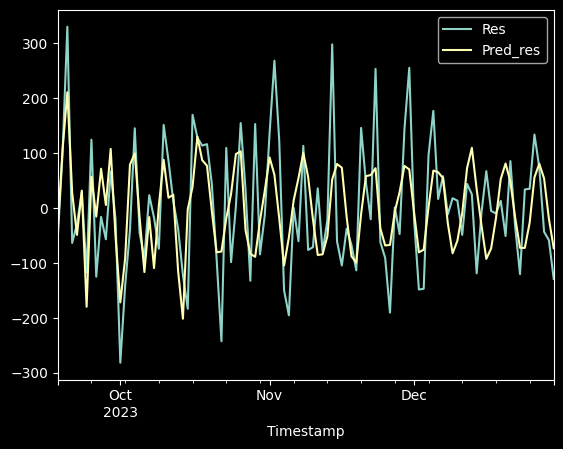

In [171]:
from statsmodels.tsa.arima.model import ARIMA
model = SARIMAX(train['Res'].dropna(),order=(3,0,3),seasonal_order=(2,0,1,30)).fit()
test['Pred_res'] = model.forecast(steps=len(test))
test[['Res','Pred_res']].plot()
rmse(test['Res'],test['Pred_res'])

Rmse:  138.60566275995384


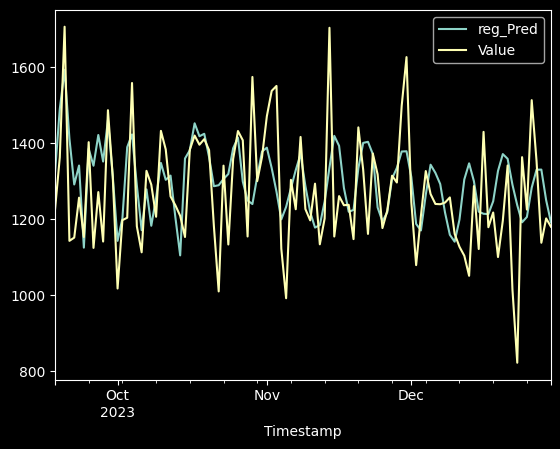

In [173]:
test['reg_Pred'] = test['reg_Trend']+test['Pred_Seas']+test['Pred_res']
test[['reg_Pred','Value']].plot()
print("Rmse: ",rmse(test['reg_Pred'],test['Value']))

this is our predicted daily traffic